                                        Bannk Churners 

                                       Objective 
The aim of this notebook is to perform a comprehensive analysis of this bank churning dataset in order to identify key demographic trends, behavioral patterns and potential indicators of attrittion by examining the relationships between the customers attributes

                                     Table of contents

                     What is EDA?

This refers to the process of scrutinizing, visualizing, and summarizing  a dataset so that  one can make reasonable conclusions based on questions raised in  observing the data. In this project, we will visualize how customers are leaving or staying in the bannk, how many transaction they frequently carrry out, their income and education level and how itrelated to why they are leavinbg the business.

First, we willimport python libararies prerequisite for this project before uploading the dataset from the local directory. This dataset can also be downloaded from www.kaggle/datasets.com

In [1]:
#importing prerequisite  python packages
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# uploading our dataset and reading its contents
df = pd.read_csv(r'./BankChurners.csv')
df.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


This dataset has 23  features showing  various customers attributes like social-economic status(income category), demographic(age and gender) and banking behaviour(Months on book, total revolving balance, total transaction counts etc). 

The target variable is Attrition flag and this notebook will focus on how other attributes influence or even show why customers are leaving the bank 

In [3]:
df.shape

(10127, 23)

This dataset has 10127 rows  and 23 columns/features

                                    Duplicate data
We will remove duplicates in our dataset since they may skew it making us to draw biased conclusions from it. Customer ID i.e ClientNUM is a unique value so useful in removing duplicated values. The shape of our dataset after removing them will proof their existence or not.

In [4]:
df = df.loc[~df['CLIENTNUM'].index.duplicated()]
df.shape

(10127, 23)

The shape of this dataset remained the same so there aren't any duplicated values in our data. Dropping columns containing naive bayes classifiersince they don't havy any input in our analysis

In [5]:
#dropping unuseful columns
df.drop(columns=['Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1', 'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2'], axis=1, inplace=True)

                         Checking null values

null values in the dataset can result to biased analysis,  reduceed completeness of the dataset etc thus they require careful handling to  remove/modify them. We will check for null values in our dataset.


In [6]:
#checking null values
df.isnull().sum()

CLIENTNUM                   0
Attrition_Flag              0
Customer_Age                0
Gender                      0
Dependent_count             0
Education_Level             0
Marital_Status              0
Income_Category             0
Card_Category               0
Months_on_book              0
Total_Relationship_Count    0
Months_Inactive_12_mon      0
Contacts_Count_12_mon       0
Credit_Limit                0
Total_Revolving_Bal         0
Avg_Open_To_Buy             0
Total_Amt_Chng_Q4_Q1        0
Total_Trans_Amt             0
Total_Trans_Ct              0
Total_Ct_Chng_Q4_Q1         0
Avg_Utilization_Ratio       0
dtype: int64

This dataset doesn't have any null values 

                           Descriptive  Statistics 
This will involve estimating various statistical  measures to our variables like mean, count, standard deviation, maximum value and minimum value and quantiles. The variables are the columns while the index is made up of the statistical parameters.

In [7]:
df.describe()

,CLIENTNUM,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
count,1.012700e+04,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
mean,7.391776e+08,46.325960,2.346203,35.928409,3.812580,2.341167,2.455317,8631.953698,1162.814061,7469.139637,0.759941,4404.086304,64.858695,0.712222,0.274894
std,3.690378e+07,8.016814,1.298908,7.986416,1.554408,1.010622,1.106225,9088.776650,814.987335,9090.685324,0.219207,3397.129254,23.472570,0.238086,0.275691
min,7.080821e+08,26.000000,0.000000,13.000000,1.000000,0.000000,0.000000,1438.300000,0.000000,3.000000,0.000000,510.000000,10.000000,0.000000,0.000000
25%,7.130368e+08,41.000000,1.000000,31.000000,3.000000,2.000000,2.000000,2555.000000,359.000000,1324.500000,0.631000,2155.500000,45.000000,0.582000,0.023000
50%,7.179264e+08,46.000000,2.000000,36.000000,4.000000,2.000000,2.000000,4549.000000,1276.000000,3474.000000,0.736000,3899.000000,67.000000,0.702000,0.176000
75%,7.731435e+08,52.000000,3.000000,40.000000,5.000000,3.000000,3.000000,11067.500000,1784.000000,9859.000000,0.859000,4741.000000,81.000000,0.818000,0.503000
max,8.283431e+08,73.000000,5.000000,56.000000,6.000000,6.000000,6.000000,34516.000000,2517.000000,34516.000000,3.397000,18484.000000,139.000000,3.714000,0.999000


In [11]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
non_numerical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(numerical_cols)
print()
print(non_numerical_cols)

['CLIENTNUM', 'Customer_Age', 'Dependent_count', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal', 'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio']

['Attrition_Flag', 'Gender', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category']


       What is the distribution of Total transaction Amount?

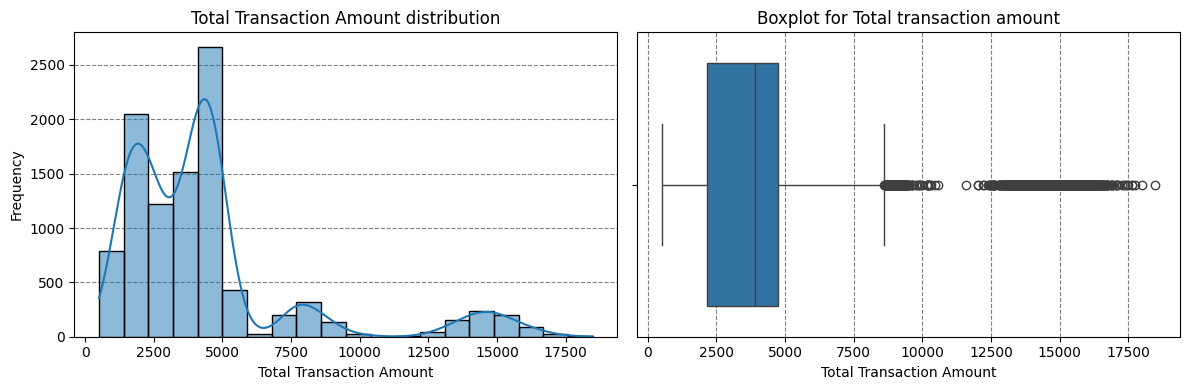

In [12]:
fig, axes = plt.subplots(1,2, figsize=(12,4))
sns.histplot(df['Total_Trans_Amt'], bins=20, kde=True, ax=axes[0])
axes[0].set_title('Total Transaction Amount distribution')
axes[0].set_xlabel('Total Transaction Amount')
axes[0].set_ylabel('Frequency')
axes[0].set_axisbelow(True)
axes[0].grid(axis='y', color='gray',ls='--')

sns.boxplot(x=df['Total_Trans_Amt'], ax=axes[1])
axes[1].set_title('Boxplot for Total transaction amount')
axes[1].set_xlabel('Total Transaction Amount')
axes[1].set_axisbelow(True)
axes[1].grid(axis='x', color='gray', ls='--')
plt.tight_layout()
plt.show()

```python
The chart on the left shows total transaction amount is  right skewed with most customers having transaction amounts below $5000, the frequent low spenders. There are 2 more smaller peaks around $7,500 and at $15000 showing different customer segments with dinstinct spending patterns .The tail extending to $ 17,500 are likely those infrequent, high-spending customers as shown by the dots in the left of the whiskers on the boxplot.
```

                       What is the ditribution of Customers Age?

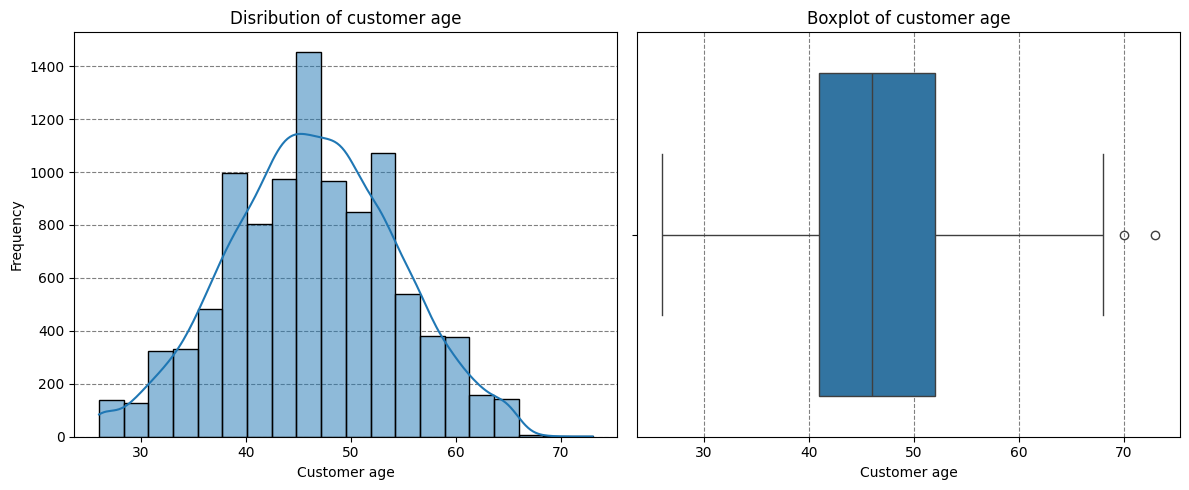

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(df['Customer_Age'], bins=20, kde=True, ax=axes[0])
axes[0].set_title('Disribution of customer age')
axes[0].set_xlabel('Customer age')
axes[0].set_ylabel('Frequency')
axes[0].set_axisbelow(True)
axes[0].grid(axis='y', color='gray', ls='--')

sns.boxplot(x=df['Customer_Age'], ax=axes[1])
axes[1].set_title('Boxplot of customer age')
axes[1].set_xlabel('Customer age')
axes[1].set_axisbelow(True)
axes[1].grid(axis='x', color='gray', ls='--')
plt.tight_layout()
plt.show()


The histogram above shows customer age is normally distributed around the 45 years  meaning there are almost equal numbersof customers who are aged more/ less than 45 . The boxplot shows that few customers are outliers as shown by dots beyond the whiskers with ages above 70 years and the distance between the 25th percentile and the median or 75th and the median is the same confirming normality of the customers age.


                               What is the distribution of Total revolving balance?

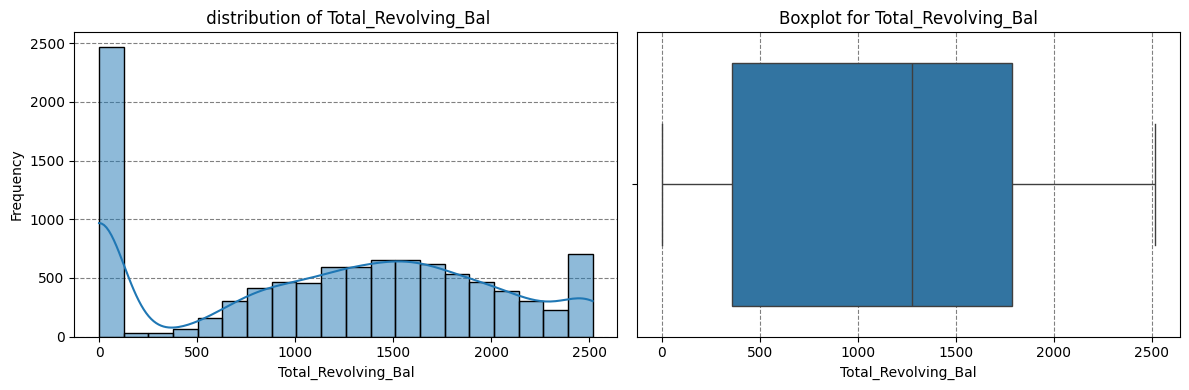

In [14]:
fig, axes = plt.subplots(1,2, figsize=(12,4))
sns.histplot(df['Total_Revolving_Bal'], bins=20, kde=True, ax=axes[0])
axes[0].set_title(' distribution of Total_Revolving_Bal')
axes[0].set_xlabel('Total_Revolving_Bal')
axes[0].set_ylabel('Frequency')
axes[0].set_axisbelow(True)
axes[0].grid(axis='y', color='gray',ls='--')

sns.boxplot(x=df['Total_Revolving_Bal'], ax=axes[1])
axes[1].set_title('Boxplot for Total_Revolving_Bal')
axes[1].set_xlabel('Total_Revolving_Bal')
axes[1].set_axisbelow(True)
axes[1].grid(axis='x', color='gray', ls='--')
plt.tight_layout()
plt.show()

the histogram shows total revolving balance has a bimodal distribution with a peak at 0 meaning most customers either pays off their balances in full at the end of the month or they are not using their credit facility and the peak arounf 1500 are the customers who carry balance month-on-month i.e customers who are profitable to the bank. The boxplot shows little variance since there are no outliers beyond the whiskers

       How are customers distributed among varous education levels?

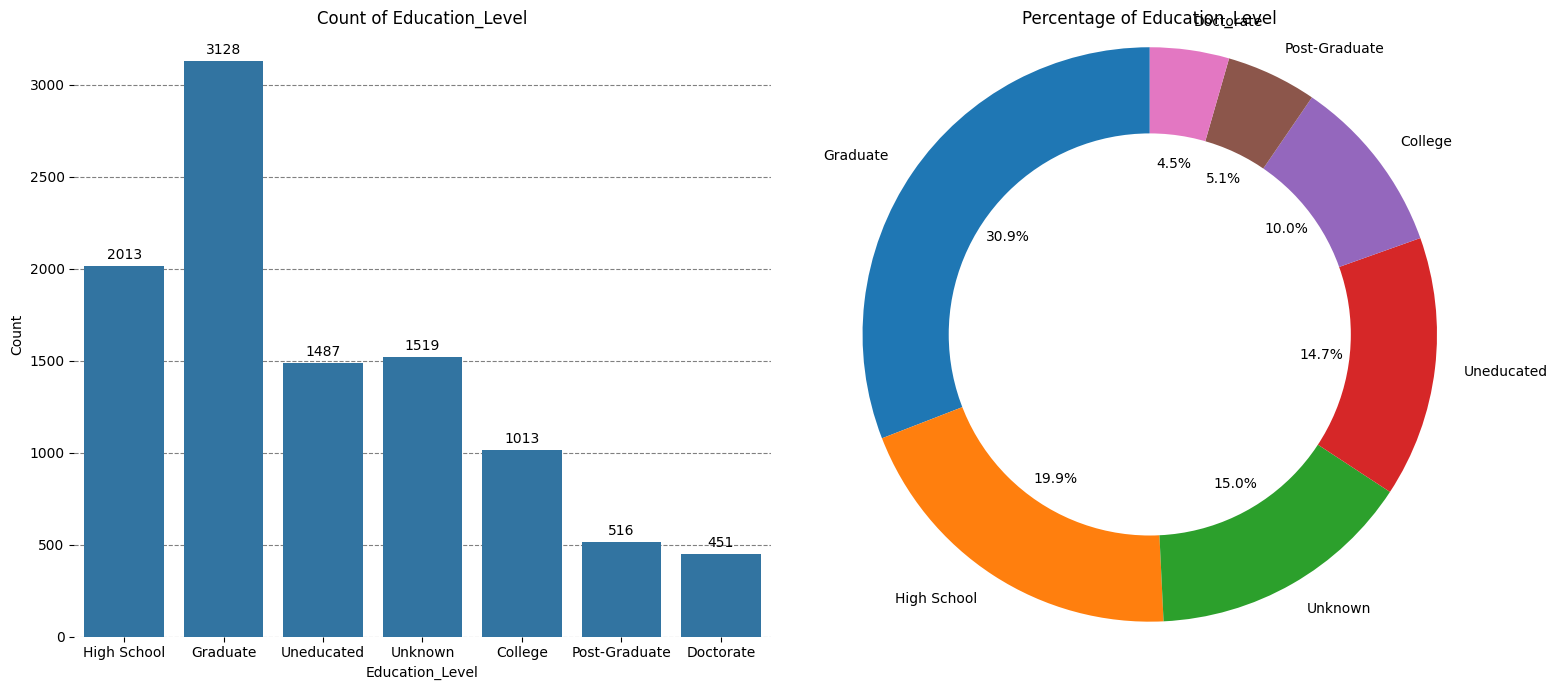

In [15]:
def plot_categorical_distribution(df, feature):
    categories = len(df[feature].unique())

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    sns.countplot(x=df[feature], ax=axes[0])
    axes[0].set_title(f'Count of {feature}')
    axes[0].set_xlabel(feature)
    axes[0].set_ylabel('Count')
    for p in axes[0].patches:
        axes[0].annotate(f'{int(p.get_height())}', 
                         (p.get_x() + p.get_width()/2., p.get_height()), ha='center', va='baseline', color='black', xytext=(0, 5), textcoords='offset points')
        axes[0].set_axisbelow(True)
        axes[0].grid(axis='y', color='gray', ls='--')
        sns.despine(left=True, bottom=True)

    feature_counts = df[feature].value_counts()
    wedges, texts, autotext =  axes[1].pie(feature_counts, labels =feature_counts.index, autopct='%1.1f%%', startangle=90 )
    center_circle = plt.Circle((0, 0),  0.70, fc='white')
    fig.gca().add_artist(center_circle)
    axes[1].set_title(f'Percentage of {feature}')
    axes[1].axis('equal')
    plt.tight_layout()
    plt.show()
plot_categorical_distribution(df, 'Education_Level')
        

Based on education level:  Most of the customers  are graduates at 3128 representing 30.9% of total customers, followed by those attended only high school at 1013 representing 19.9%, with uneducated at 1487 entries  reprsenting 14.7%  while doctorates are the least at 451 customers representing a meagre 4.5% of total customers.



           How are customers distributed along various card categories?

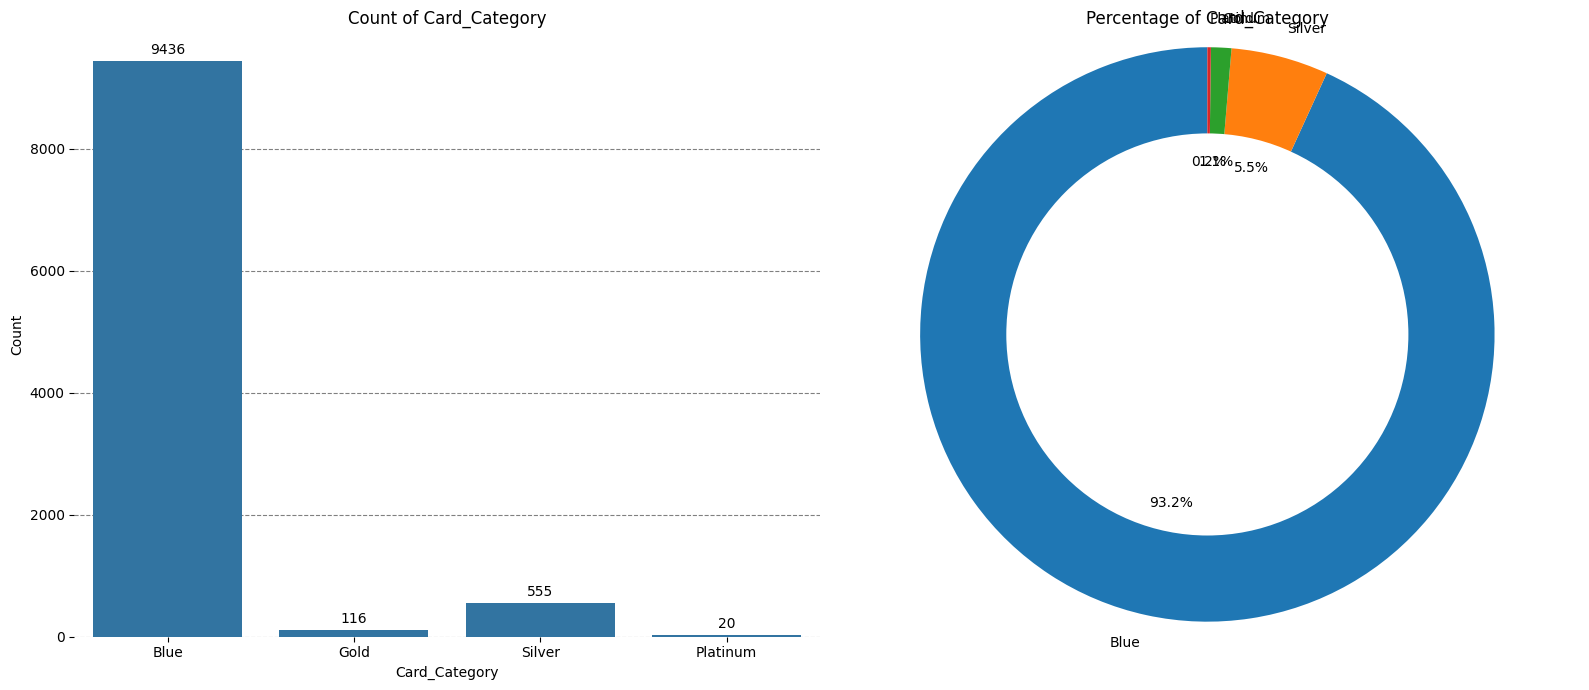

In [16]:
plot_categorical_distribution(df, 'Card_Category')

Blue card holders are the majority repersenting 93.2% of the total customersbase at 9436 customers, followed by silver card holders with 555 customers repsenting 5.5% of the total while platinum had least with 20 customers.

Conclusion: 

            How are customers ditributed at various incoome segements?

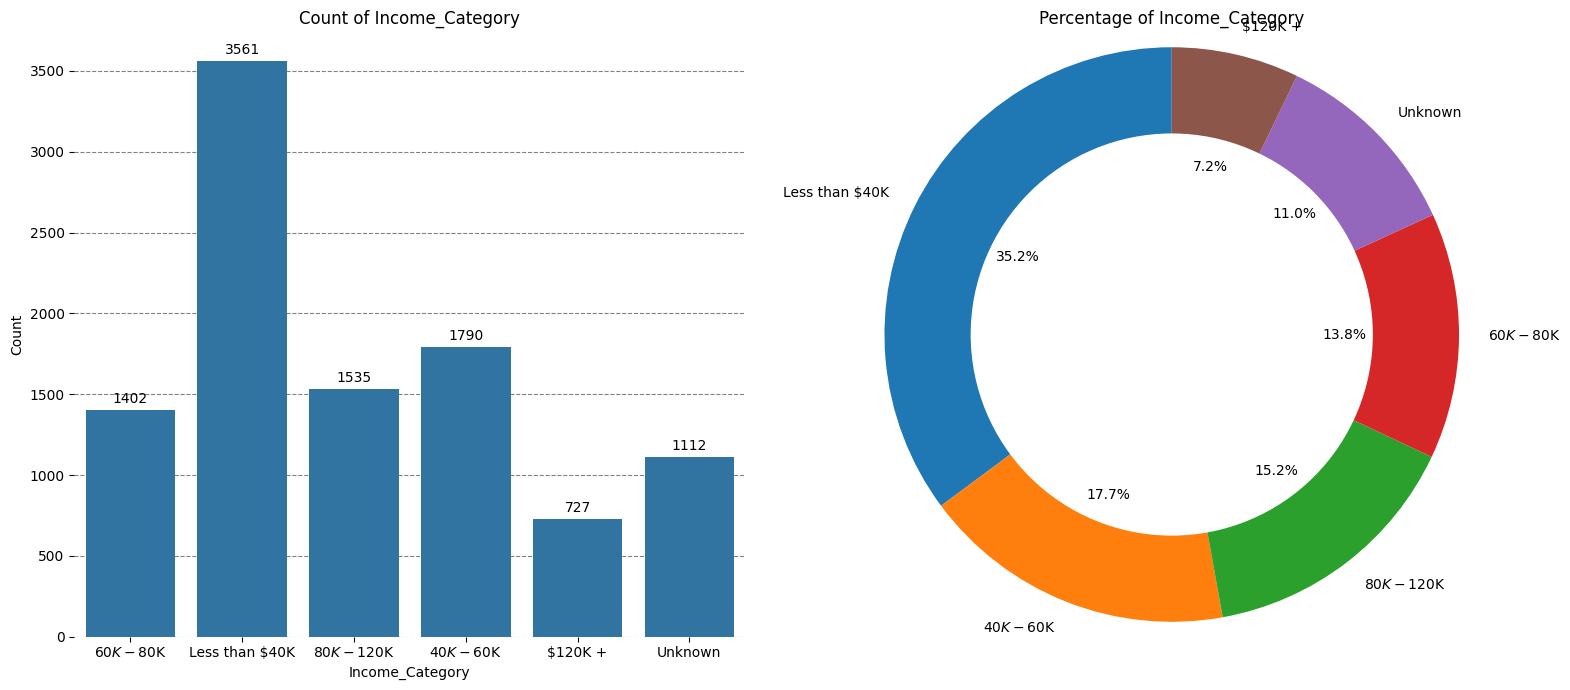

In [17]:
plot_categorical_distribution(df, 'Income_Category')

the bar chart shows Customers earning less than $40k were the majority at 3,561 customers representing 45.2% of the total customer base, follwed by customers earning between $40k-$60k at 1790 customers repsenting 17.7%of the total customers, while customers earning more than $120k dollars were the few at 727 customers repesenting 7.2%of the total customers.

              What is the marital status of our customers?

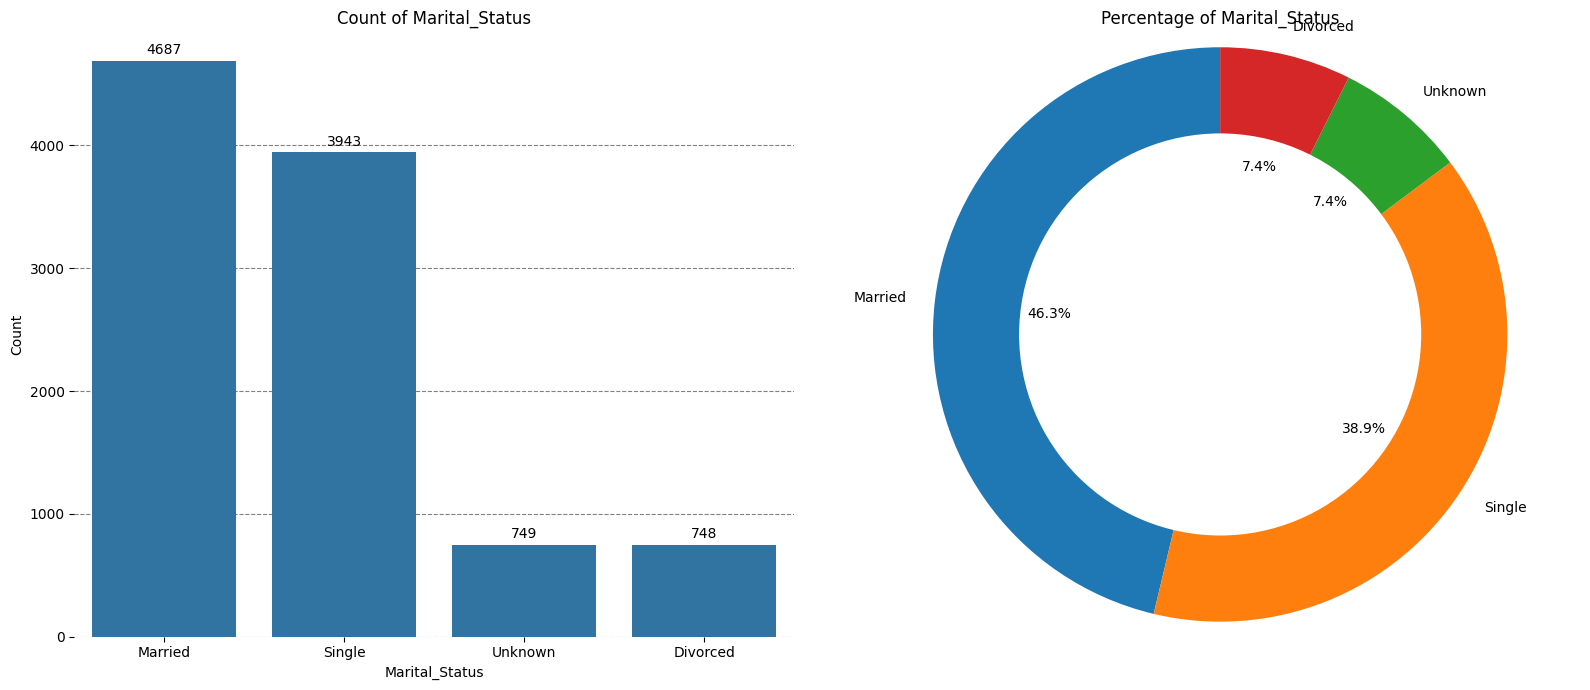

In [18]:
plot_categorical_distribution(df, 'Marital_Status')

customers in married category at 4,687 customers are the majority reprsenting 46.3% of total customer base, closely followed by thoe in single category at 3,943 customers repsenting 38.9% of the total customers while Unknown and Divored ar the least with both having 748 entries thus each  reprsenting 7.4% of the total customer base.

Unknown customers  i will arbitrary treat them as customers who preferred anonymity.

In [19]:
df.columns

Index(['CLIENTNUM', 'Attrition_Flag', 'Customer_Age', 'Gender',
       'Dependent_count', 'Education_Level', 'Marital_Status',
       'Income_Category', 'Card_Category', 'Months_on_book',
       'Total_Relationship_Count', 'Months_Inactive_12_mon',
       'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal',
       'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt',
       'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio'],
      dtype='object')

                                        Bivariate analysis

In [20]:
def bivariate_percent_plott(cat, df, figsize=(15, 6), order=None, rot=0):
    print('Distribution of flag by {cat}')
    fig, ax = plt.subplots(nrows= 1, ncols=2, figsize=figsize)
    grouped = df.groupby([cat, 'Attrition_Flag'], observed=True).size().unstack(fill_value=0)
    if order is not None:
        grouped = grouped.reindex(order)
    percentages = grouped.div(grouped.sum(axis=1), axis=0)* 100 
    percentages.plot(kind='bar', stacked=True, color=sns.color_palette('vlag', 2), ax=ax[0])
    for container in ax[0].containers:
        ax[0].bar_label(container, fmt='%1.0f%%', label_type='center', weight='bold', fontsize=10)
        ax[0].set_title(f'Percentage of Attrition by {cat}')
        ax[0].set_ylabel('% Attrition rate ')
        ax[0].legend(title='Attrition Flag', loc='upper right')
    
    sns.countplot(data=df, x=cat,  hue='Attrition_Flag', palette=sns.color_palette('vlag', 2), ax=ax[1], order=order)
    for container in ax[1].containers:
        ax[1].bar_label(container, fmt='%d', label_type = 'edge', fontsize=10, weight='bold')
        ax[1].set_title(f'Attrition counts  by {cat}')
        ax[1].set_xlabel({cat})
        ax[1].legend(title = 'Attrition', bbox_to_anchor=(1.05, 1), loc='upper left')
        sns.despine(ax=ax[0])
        sns.despine(ax=ax[1])

        current_rot = 45 if cat in ['Education_Level', 'Income_Category'] else rot 
        for a in ax:
            a.tick_params(axis='x', rotation=current_rot)
    
    from scipy.stats import chi2_contingency 
    contigency_table = pd.crosstab(df[cat], df['Attrition_Flag'])
    chi2, pval, dof, expected = chi2_contingency(contigency_table)
    result_text = f'Chi square p_value: {pval:.4f}'
    status = "statistical Significant" if pval < 0.05 else 'not statistical  significant'
    print(f'Results: {status} of {cat} ({result_text})')

    plt.tight_layout()
    plt.show()

     What is the level of attrition in relation to gender?

Distribution of flag by {cat}
Results: statistical Significant of Gender (Chi square p_value: 0.0002)


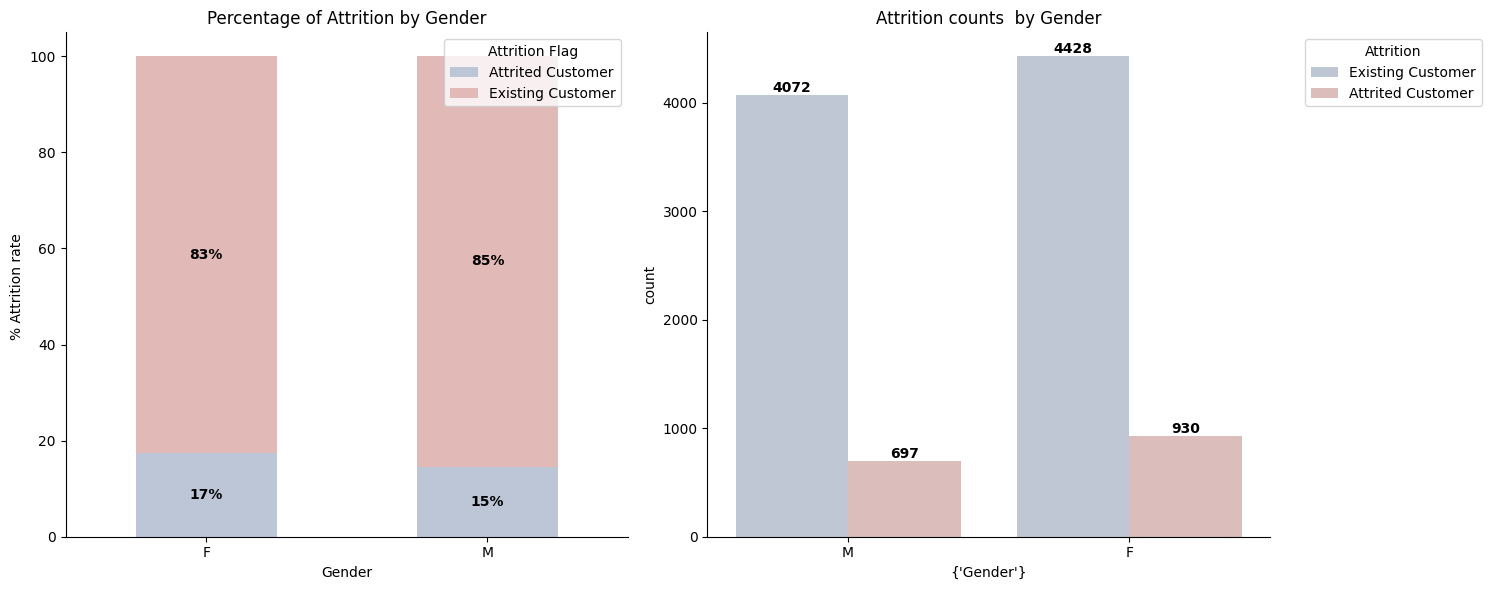

In [21]:
bivariate_percent_plott('Gender', df)

Exististing customers who are feamles are 4,4428 repsenting 83% of total female customers while 17% represent 930 attrited ones. On male customers, 4072 repsenting 83% are the existing customers while 15% of the total male customers at 697 are attrited cuustomers.

verdict: While  p-value < 0.05 meaning this column is not significant in driving attrition, but females are  marginally larger customer base at 5358 comapred to males at 4,769  and they have 2% high attrition rate above males the bank should conduct surveys on why mot women are leaving and find ways of retaining them. The should use the same startegy to find males are leving the bank.

                What is the educational level of our customers in relation to attrtion?

Distribution of flag by {cat}
Results: not statistical  significant of Education_Level (Chi square p_value: 0.0515)


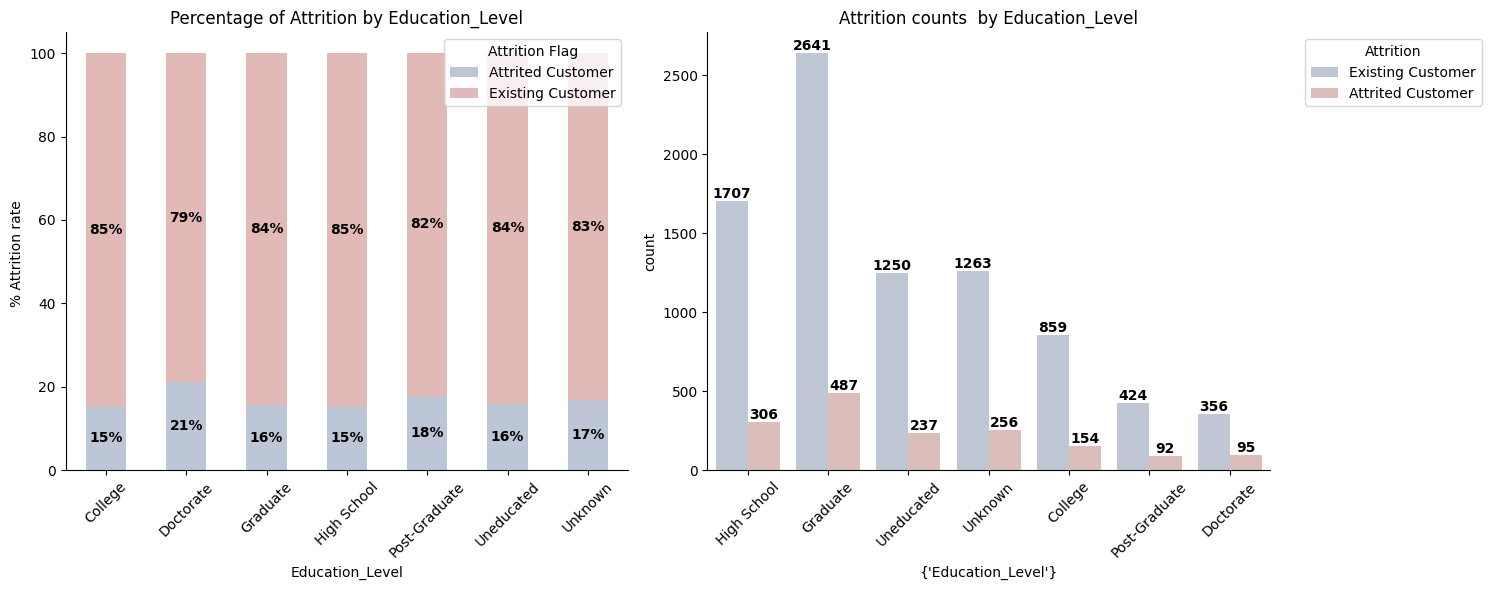

In [22]:
bivariate_percent_plott('Education_Level', df)

On volume, graduates are leaving at a higher rate at 487 customers, followed by those  from High school level with 306 attrited customers while post-graduates are least 92 attited customers. On proportions, Doctorate have the highest churn rate at 21% of total doctorate customers, Post-Graduates at 16% of total post-graduate customers while High school have the lowest churn rate at 15%.

Verdict: With a p-value of 0.0515 this means education level is not that higly significant in ifluencing attrition among customers. Churning rate is stable among all education levels ranging from 21% - 15%. 

            What is the rate of attrition in relation to Income category?

Distribution of flag by {cat}
Results: statistical Significant of Income_Category (Chi square p_value: 0.0250)


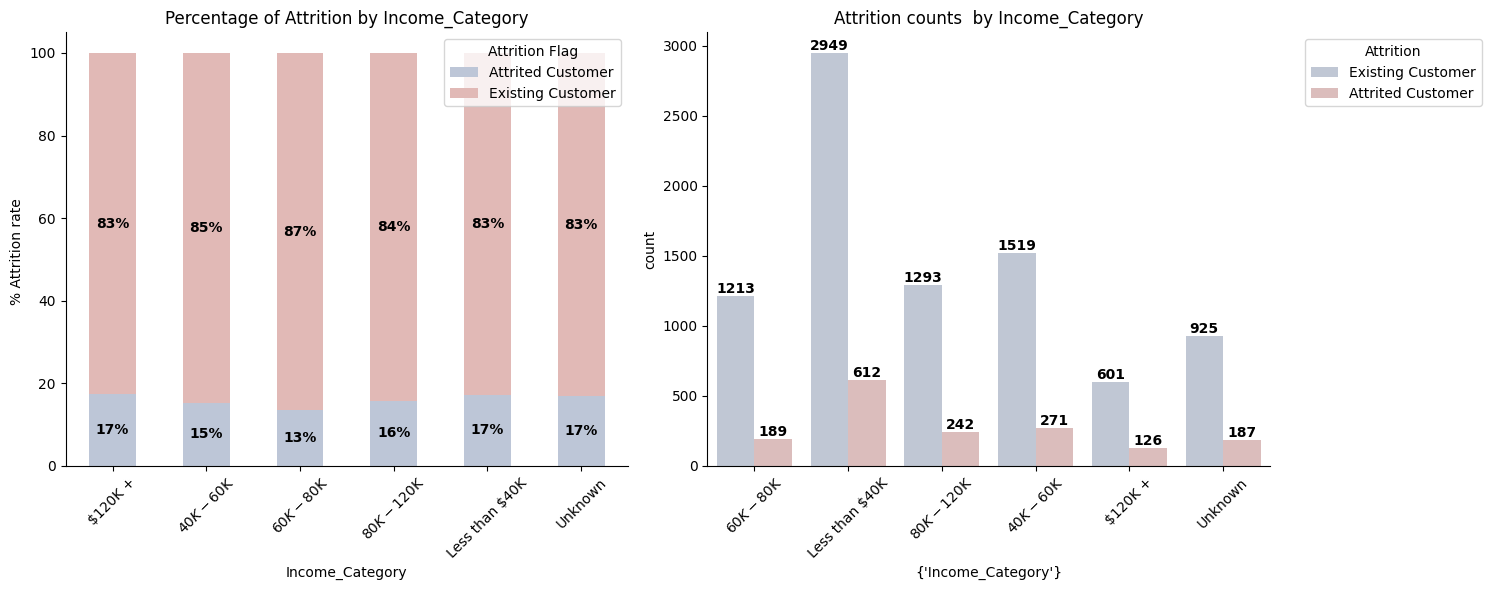

In [23]:
bivariate_percent_plott('Income_Category', df)

On volume level, customers earning 'less than $40k' are leaving at higher rate with 612 customers, followed by those earning '$80k-$120k at 242 customers while those customers earning more than $120K ar the least at126 customers.
On proprtions, churning rate is high on customers aerning more than $120k at 17%, followed by those earning  $80k-$120k at 16% while  those earning $60k-$80k have the least proprtion of churners at 13%.

conclusion: Income category has a p-value of  0.0250 thus it is not significant in driving customer attrition. The attrtition rate varry between 17% - 13%  so its stable but the bank should check why the rate of customers aeraning more than $120k are leaving and reasons for those earning less than 40k areleaving the bank.

         How does card category drives  customer attrtion?

Distribution of flag by {cat}
Results: not statistical  significant of Card_Category (Chi square p_value: 0.5252)


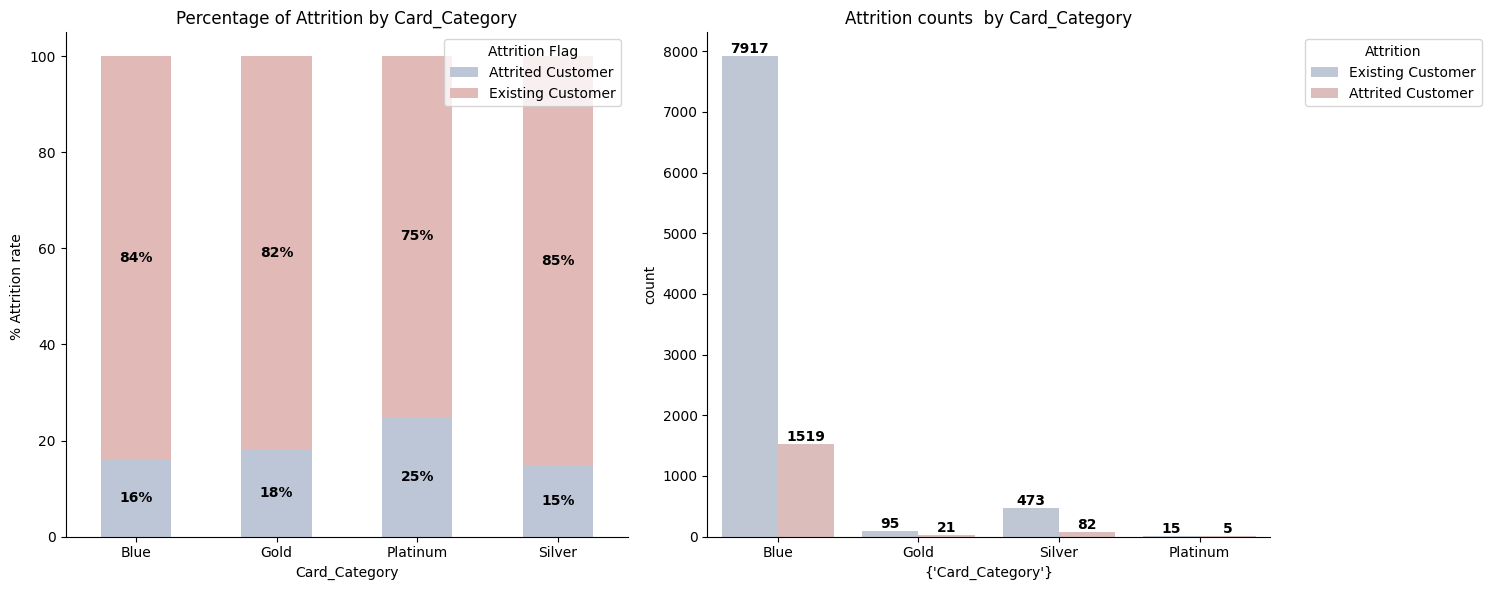

In [24]:
bivariate_percent_plott('Card_Category', df)

Blue card holders are the largest group at 9,436 custoomerswith attrited customers at 1519, followed by silver card holders at 82 attrited customers while platinum card holders as the least with 5 attrited customers.

On proportions, Platinum has the highest churning rate at 25%, followed by gold card holders at 18% while silver cardholders have the lowest churning rate at 15% .

verdict: With a p-value of 0.5252, Card category is significant driver of attition since it conveys to spending habits of th customers. Platimun cardholders while they the tiny at 20 customers they have the highest churning rate of 25% followed by Gold at 18% but this might be base effect due to their low category. Blue card holders at 16% are the ones that may affect the bank more since they are the nmost representative given thir large ize.

                     How does  marital status relate to attrtion of a customer?

Distribution of flag by {cat}
Results: not statistical  significant of Marital_Status (Chi square p_value: 0.1089)


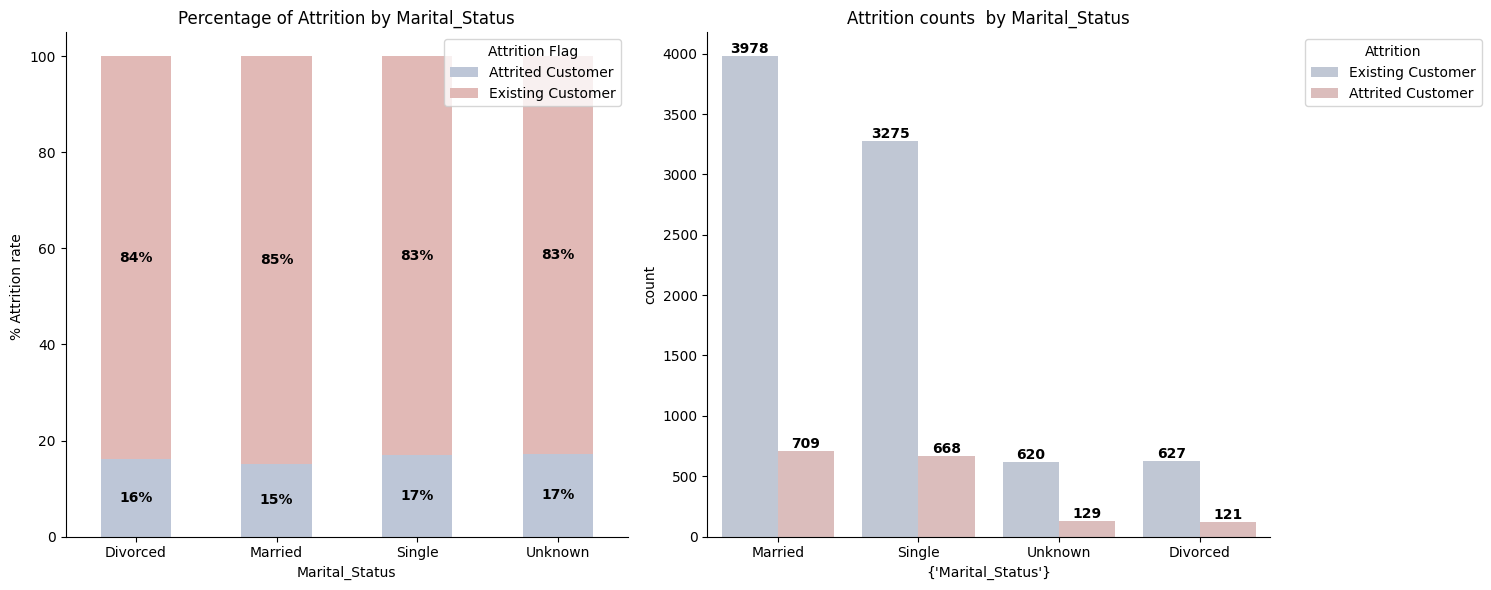

In [25]:
bivariate_percent_plott('Marital_Status', df)

Married customers are the largest group at 4,687 of whom 709 are attrited customers, followed by single customers at 3,943 of whom 668 are attrited customers while divorced are the least 748 customers of whome 121 are attrited.

single customers have the highest attrition rate at 17% slighly bigger than divorced at 16% while married ocustomers have 15%. The single customers maybe have the highest attrition rate due to low switching cost from bank products, financial pressure etc while divorced customers due to finacial distres resulting from divorce, ending joint accounts, asset liquidations etc. 

Note: I'm treating customers labelled unknown as those customers who didn't want to sepcify their marital status rather data entry error.

            How much of customers's available credit they are using in relation to relationship count?

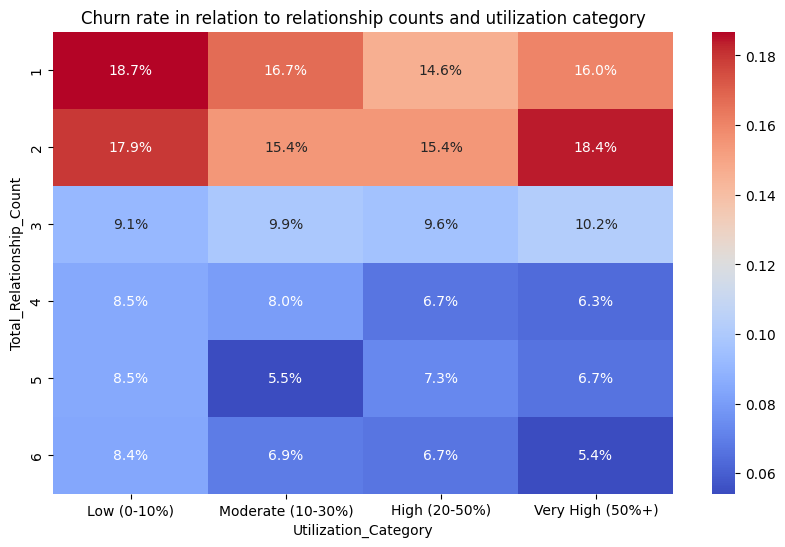

In [26]:
df['Utilization_Category'] = pd.cut(df['Avg_Utilization_Ratio'], bins = [0, 0.1, 0.3, 0.5, 1.0], 
labels = ['Low (0-10%)', 'Moderate (10-30%)', 'High (20-50%)', 'Very High (50%+)'])

SMatrix = df.groupby(['Total_Relationship_Count', 'Utilization_Category'], observed=True)['Attrition_Flag'].value_counts(normalize=True).unstack()
churnHeatmap = SMatrix['Attrited Customer'].unstack()
plt.figure(figsize =(10, 6))
sns.heatmap(churnHeatmap, annot=True, cmap='coolwarm', fmt='.1%')
plt.title('Churn rate in relation to relationship counts and utilization category')
plt.show()

The heatmap above shows there is high churn rate when a customer has lower total relationship count at all utilization ratios with churn rate  being more than 14% when a customerhas less than 2 bank products. Churn rates are low for customers having more than 4 bank products  averaging at 7.08% but there is heightned churn rate among customers with lowest utilization category of 'Low (0-10%)'  of more than 8.4% regardless of the number of bank products a customer have.

Customers with moderate (10-30%) and very high(50%+) utilzation levels have the lowest churn rate at 5.5% when the former has 5 bank products and 5.4% when the latter has 6 products.

conclusion:  Customers with less than 2 bank products have high churn rate regardless of utilzation level due to low switching costs from one bank to another since they are notdeeply integrated into the bank ecosystem while those with more than 4 bank products have lower rates due to high switching costs. Customers with 0-10% utilization levels have high churn rate than other levels regardless of how many babnk products they have.

In [27]:
df['Total_Revolving_Bal'].describe()

count    10127.000000
mean      1162.814061
std        814.987335
min          0.000000
25%        359.000000
50%       1276.000000
75%       1784.000000
max       2517.000000
Name: Total_Revolving_Bal, dtype: float64

In [28]:
df['Revolving_Balance'] = pd.cut(df['Total_Revolving_Bal'], bins=[0, 504, 1008, 1512, 2016, 2520], labels = ['Very Low (0-504)', 'Low (504 -1008)', 'Moderate (1008-1512)', 'High(1500-2016)',  'Very High (2016+)'])
#bivariate_percent_plott("Revolving_Balance", df, rot=30)

           How doees Revolving balance and total relationship count drive customers churning rate?

Text(0.5, 1.0, 'Churn rate in relation to Revolving balance and Total_Relationship_Count')

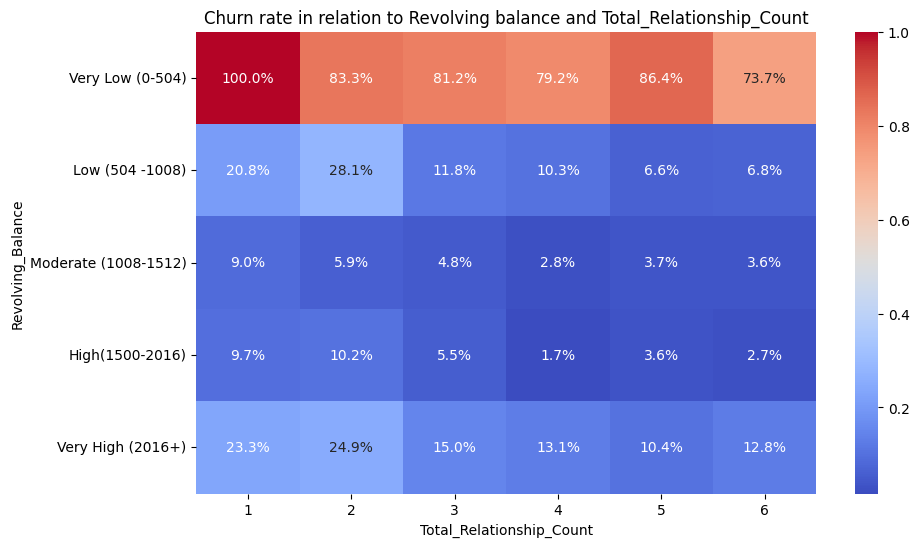

In [29]:
SMatrix = df.groupby(['Revolving_Balance', 'Total_Relationship_Count'], observed=True)['Attrition_Flag'].value_counts(normalize=True).unstack()
churnHeatmap = SMatrix['Attrited Customer'].unstack()
plt.figure(figsize =(10, 6))
sns.heatmap(churnHeatmap, annot=True, cmap='coolwarm', fmt='.1%')
plt.title('Churn rate in relation to Revolving balance and Total_Relationship_Count')

customers with revolving balance of (0-504) have attrition rates more than 79% across all total relationship counts with a 100% churn rate when a customer has 1 bank product. Customers with moderate and high revolving balances have low churn rates averaging 3.01%  if they have more than 4 bank products. There is also high churn rates  for customers with very high revolving balance  especially if they have less than 3 bank products.

Conclusion: customers with very high revolving balances especially thoe with less than 3 bank products have high churn rates due to finacial distress  while those with very low revolving balances are mostly those customers who use the card for convenience but pays it immediately thus the bank doesn't earn interest. Customers with moderate and high revolving balance are the stable ones who earn the bank interest and deeply entreched in bank ecosystem thus have low churn rates due to high switching costs.

In [30]:
df['Avg_Open_To_Buy'].describe()

count    10127.000000
mean      7469.139637
std       9090.685324
min          3.000000
25%       1324.500000
50%       3474.000000
75%       9859.000000
max      34516.000000
Name: Avg_Open_To_Buy, dtype: float64

            Finacial distress of custmers in the bank

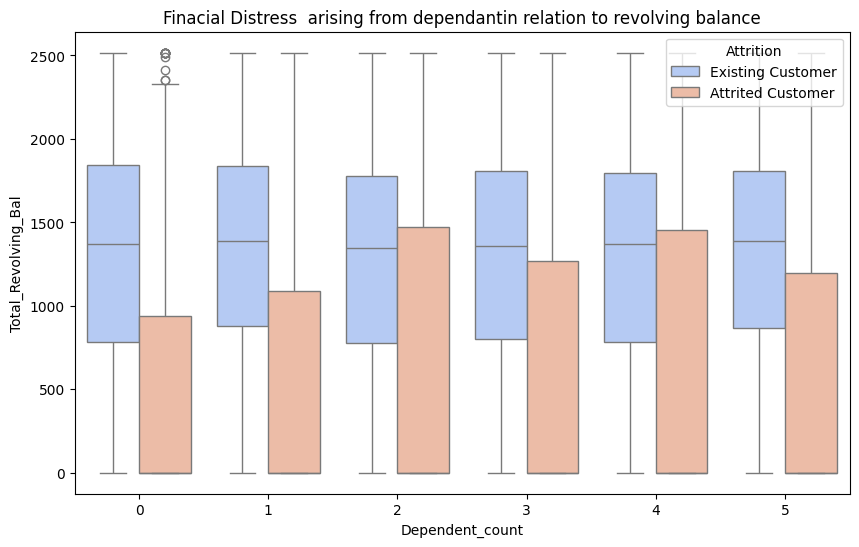

In [31]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['Dependent_count'], y=df['Total_Revolving_Bal'], hue=df['Attrition_Flag'], palette='coolwarm')
plt.title('Finacial Distress  arising from dependantin relation to revolving balance')
plt.legend(title='Attrition', loc='upper right')
plt.show()

finacial distress increases and the risk of churning are high when revolving balance is low since the chart shows existing customers have stable revolving balance with the median ranging between $1000 - $1500  while the attrtited customers have no median and the box-plots are lower than the median of existing customers meaning they have very small (close to zero if you factor the bimodal distribution of total revolving balance) depicting that customers with higher revolving balamce have hig switching costs.

On dependents, whether an exiting customer has 0 or 5 dependents the chart shows they are stable and similar while thoe who churn  have increasing meadians of revolving balance with a drop in customers with 3 dependents meaning they are vey sensitive to a drop in revolving balance.

In [32]:
df['Income_Category'].value_counts()

Income_Category
Less than $40K    3561
$40K - $60K       1790
$80K - $120K      1535
$60K - $80K       1402
Unknown           1112
$120K +            727
Name: count, dtype: int64

             What is the churn rate and density of customers in an income segment in relation to dependent counts?

In [40]:
def plot_dualHeatmaps(df):
    churn_matrix =  (df.groupby(['Income_Category', 'Dependent_count'], observed=True)['Attrition_Flag'].value_counts(normalize=True).unstack(fill_value=0)['Attrited Customer'].unstack())
    density_matrix = df.groupby(['Income_Category', 'Dependent_count'], observed=True)['Attrition_Flag'].size().unstack(fill_value=0)
    
    fig, ax = plt.subplots(1, 2, figsize=(16, 6))
    sns.heatmap(churn_matrix * 100, annot=True, fmt='.1f', cmap='coolwarm', ax=ax[0])
    #sns.heatmap(churn_matrix, annot=True, fmt='d', cmap='coolwarm', ax=ax[0])
    ax[0].set_title('Churn rate %: Income vs household')
    ax[0].set_xlabel('Number of dependents')
    ax[0].set_ylabel("Income Category")

    sns.heatmap(density_matrix, annot=True, fmt='d', cmap='coolwarm', ax=ax[1])
    ax[1].set_title('Density of customers in: Income vs household')
    ax[1].set_xlabel('Number of dependents')
    ax[1].set_ylabel("Income Category")
    plt.tight_layout()
    plt.show()

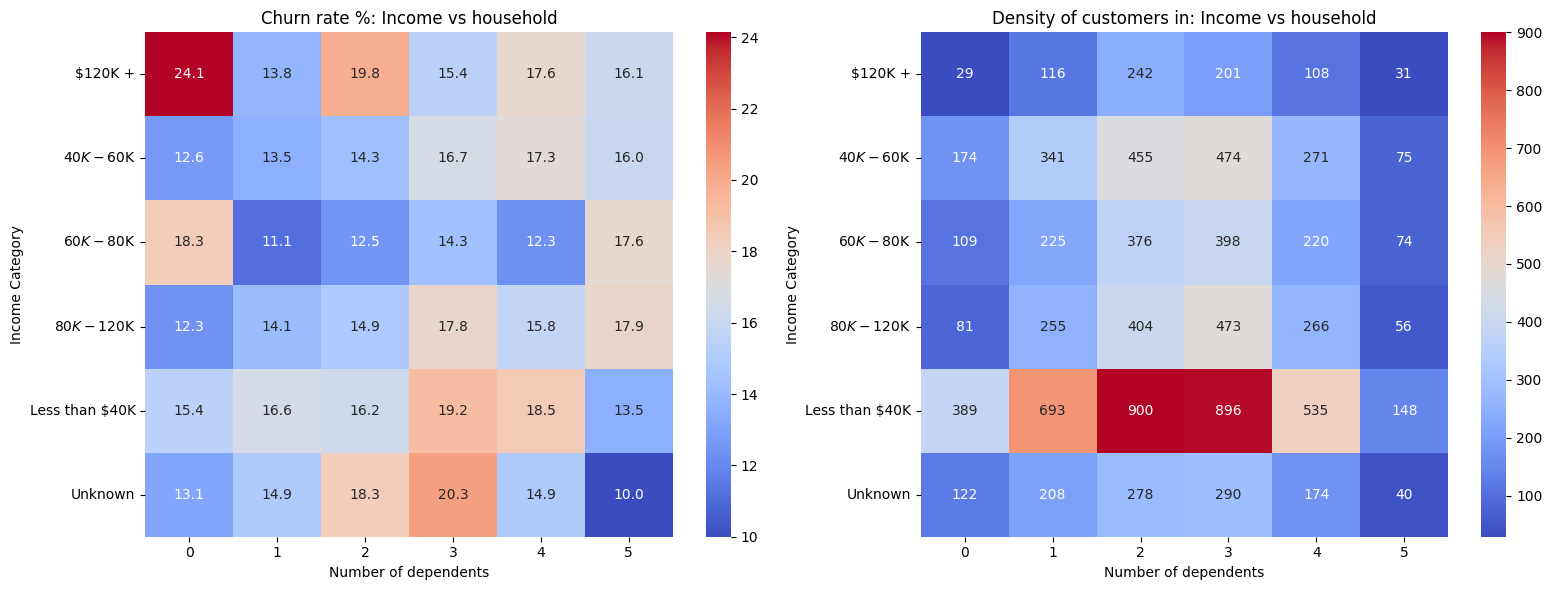

In [41]:
plot_dualHeatmaps(df)

The above heatmaps hows that while  customers earning more than $ 120k  with zero dependants had the highest rate of attrtion at 24.13%, there are eonly 29 such customers thus attributing that higher rate to smaller group bias but customers earning less than $40k  had a higher churning rate of mean 17.8 with notable high churning rate of 19.9% and 18.5% when they had  2 or 3 dependants given their high densities of 900 and 896 customers.

Customers earning between $40k to $120k  had stable  churning rate of less thyan 14% when they have less than 3 dependants with only those earning $60k-80K and having 0 dependants being an outlier with 18.3% churning rate. These customers have the  lowest churning rate but high density of customers showing that they are the loyal  and stable customer segments.

Conclusion: customers earning more than $120k  with 24.1% churning rate are a statistical noise given its low density of customers but consideration should be taken to cutomers earning less than $40k who are high churners and with high customers density since they are the core customers of the bank.

In [35]:
df['Total_Trans_Ct'].describe()

count    10127.000000
mean        64.858695
std         23.472570
min         10.000000
25%         45.000000
50%         67.000000
75%         81.000000
max        139.000000
Name: Total_Trans_Ct, dtype: float64

              How does transactions counts relate to attrition of customers?

Distribution of flag by {cat}
Results: statistical Significant of Transaction_count_categories (Chi square p_value: 0.0000)


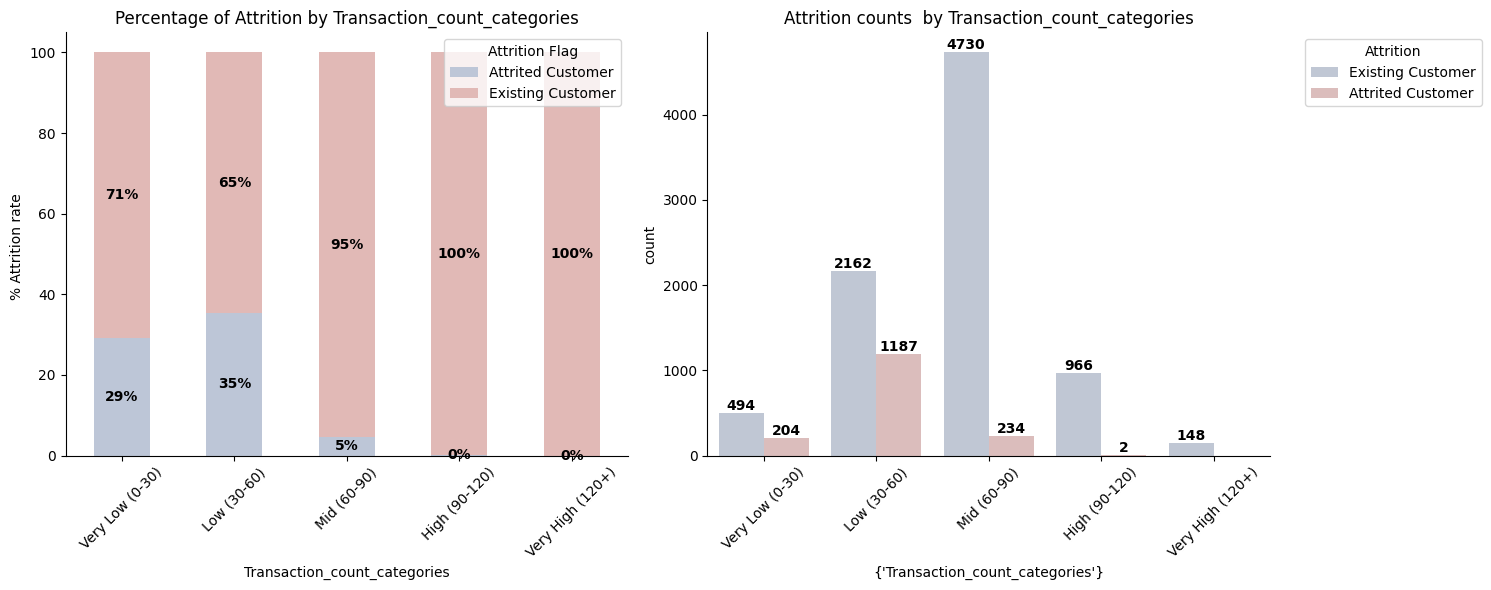

In [36]:
df['Transaction_count_categories'] = pd.cut(df['Total_Trans_Ct'], bins=[0, 30, 60, 90, 120, 150], labels = ['Very Low (0-30)', 'Low (30-60)', 'Mid (60-90)', 'High (90-120)', 'Very High (120+)'])
bivariate_percent_plott('Transaction_count_categories', df, rot=45)

customers with transactiuon counts between 30-60 had the highest churning rate of 35% with more than 1187 customers leaving, followed by those having less than 30 transaction counts with 204 leaving out of 700 customers. Customers with more than 90 transaction counts had 0% churn rate with those between 60-90 transaction counts having a tiny churning rate of 5%.

Conclusion: This shows that transaction count has an inverse relationship with attrtion with those costomers having high churning rate being the ones that use the bank products less often thus few switching costs to other means or other competitors while customers with transaction counts more than 90 had 0% churning rate meaning they use the banks' products for primary transactions and those with 60-90 having a small churning rate of 5% showing they are loyal customers with high switching costs.


             What is distribution of customers in relation to attrtion?

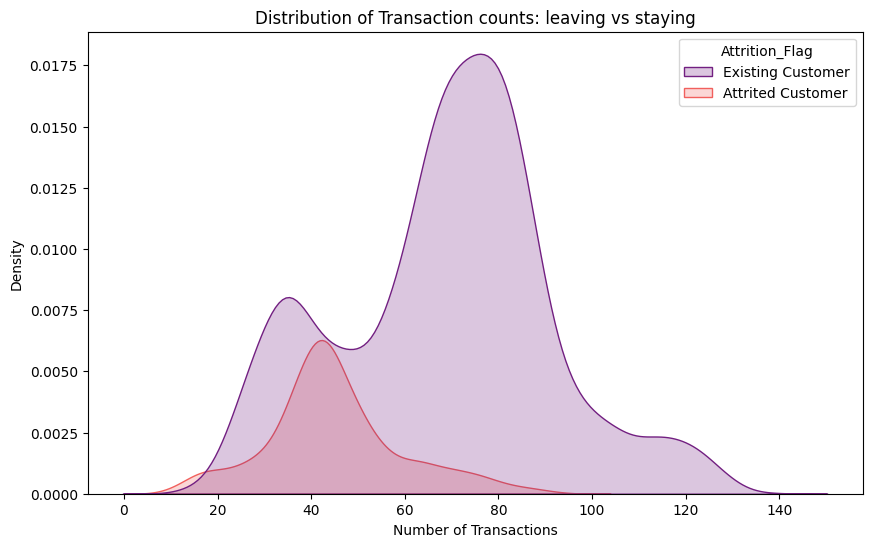

In [37]:
plt.figure(figsize=(10, 6))
sns.kdeplot(x=df['Total_Trans_Ct'], hue=df['Attrition_Flag'], fill=True, palette='magma')
plt.title('Distribution of Transaction counts: leaving vs staying')
plt.xlabel('Number of Transactions')
plt.show()

The kde plot above shows attrited customers have a low density plot peaking at 40 transaction counts with extremes close to 100 transaction counts but existing customers have the highest peak at 80 transaction counts with the right tail reaching  more than 140 total transaction counts.


            What is the velocity of tranactions  among customer segments  and how it drives attrition?

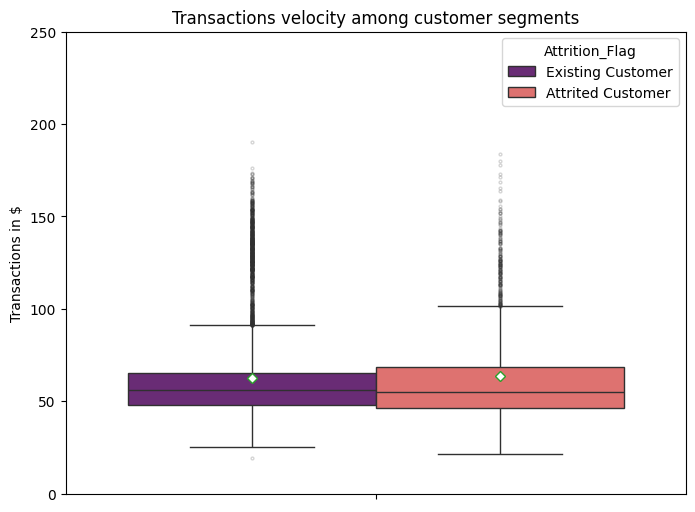

In [38]:
df['Avg_transaction_size'] = df['Total_Trans_Amt'] / df['Total_Trans_Ct']
df['Avg_transaction_size'].describe()
df['Velocity_Bin'] = pd.cut(df['Avg_transaction_size'], bins=[0, 50, 100, 150, 200], labels = ['Micro (0-50)', 'Small (50-100)', 'Medium (100-150)', 'Large (150+)'])
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['Avg_transaction_size'], hue=df['Attrition_Flag'], palette='magma', showmeans=True, flierprops={'marker': 'o', 'markersize':2, 'alpha':0.2}, 
            meanprops={'marker': 'D', "markerfacecolor": '#fff', "markersize": 5})
plt.title("Transactions velocity among customer segments")
plt.ylabel('Transactions in $')
plt.ylim(0, 250)
plt.show()


Eixting customers have lower inter-quantile range showing lower transaction sizes  around $50 compared to attrited customers thus they are the loyal customers who use the bank products for frequent, everyday low transaction size purchases while attrtited customers have a higher inter-quartile range meaning they use the bank for larger transactions than existing customers but they're less frequent. To reduce attrition the bank should should offer incentives to customers focusing more on frequency of usage rather than transaction amount.

There are outliers in both segments who have  transaction sizes more than $100 - $200 and the bank should flag customers with transaction size greater than $100 if their transaction counts start to dip thus minimizing their churn rate.

          How does customers engege with the bank?

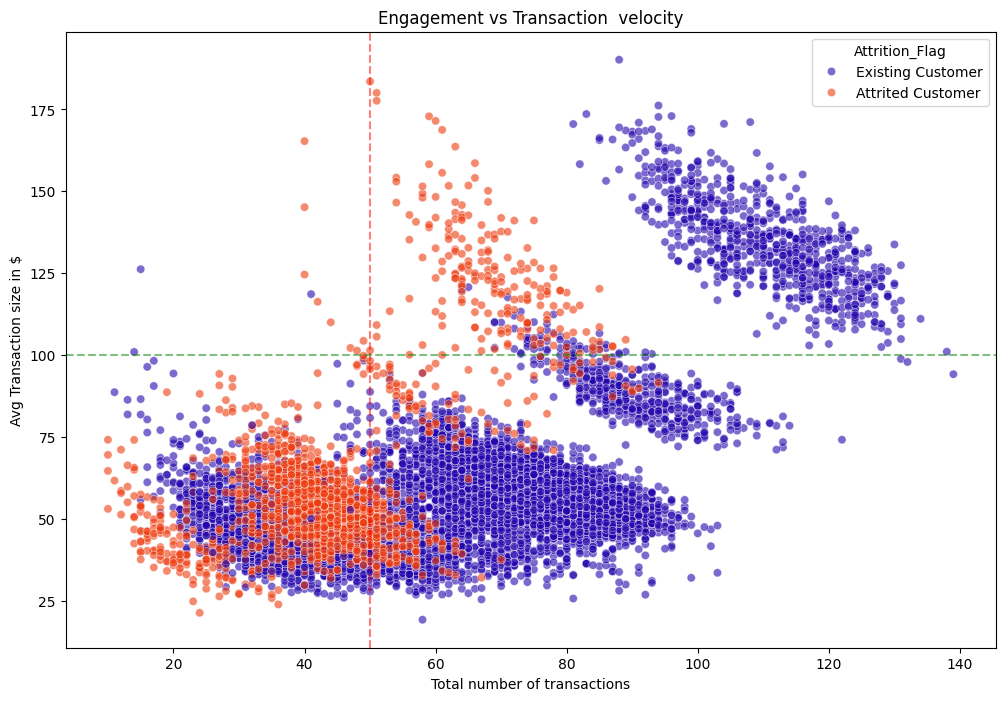

In [39]:
plt.figure(figsize=(12, 8))
sns.scatterplot(x=df['Total_Trans_Ct'], y=df['Avg_transaction_size'], hue=df['Attrition_Flag'], alpha=0.6, palette={'Existing Customer': "#2305AD", 'Attrited Customer': "#ee3a0d"})
plt.axvline(x=50, color='red', ls='--', alpha=0.5)
plt.axhline(y=100, color='green', ls='--',alpha=0.5)
plt.title('Engagement vs Transaction  velocity')
plt.xlabel('Total number of transactions')
plt.ylabel('Avg Transaction size in $')
plt.show()

Most of the existing customers are those with transaction counts ranging from 60 - 120 and transaction sizes raging from 25- 100 for loyal, low spenders, frequent customers with higher spenders with transaction size of 
$100 - $125  and high transaction counts of  80 - 140 depiicting their high level of engagement with the bank products and hence high switching costs while 

Churners are highly concetrated  where transaction counts are less than 50 and transaction size ranging from $25 - $75 showing they have low engagement with the bank products thus they don't use them frequently in their daily 
transactions.  There are high spenders who are churners but even their transactionb counts ranges from 60 - 90 howing they have less engagement with the bank even if they usually do high transaction amounts.